# Mosaic integration: Mixed, without shared modality, every method

This notebook runs every method that has a variant for mosaic Mixed, without shared modality on `D49mini`: Multigrate, StabMap and scMoMaT. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/mosaic_unshared/) explains each step and runs StabMap and scMoMaT only.

Methods run on Linux. The environments are 3 envs, 6.3 GB to download on a CPU host, 9.9 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D49mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["Multigrate", "StabMap", "scMoMaT"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,scmb_multigrate2,[Multigrate],have
1,scmb_r,[StabMap],have
2,scmb_torch,[scMoMaT],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D49mini", "mosaic", methods=METHODS,
                  out_dir="out/D49mini_all")
res.summary

[run_all] 9 more rows need files this folder does not have. mtb.scan shows them.


[run_all] Multigrate (mosaic/D49mini) ...


[run_all]   Multigrate needs about 1,300 cells in every batch of a mosaic run, 1,500 to be safe. It holds a tenth of the cells out for validation and draws 128 per batch. With fewer, training stops with an error about reconstruction_loss_validation.


[run_all]   -> CHAIN_OK (108.6s) ARI 0.426


[run_all] StabMap (mosaic/D49mini) ...


[run_all]   -> CHAIN_OK (11.3s) ARI 0.375


[run_all] scMoMaT (mosaic/D49mini) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (103.5s) ARI 0.423


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,Multigrate,CHAIN_OK,108.6,embedding,"[4500, 15]",0,cty1.csv+cty2.csv+cty3.csv,0.8043,file_of_origin,3,...,0.4780,0.4785,0.2878,0.9518,0.8785,0.7443,0.6095,None,"Multigrate needs about 1,300 cells in every ba...",
1,StabMap,CHAIN_OK,11.3,embedding,"[4500, 50]",0,cty1.csv+cty2.csv+cty3.csv,0.6602,file_of_origin,3,...,0.4054,0.4612,0.3729,0.9688,0.7121,0.7709,0.1546,None,,
2,scMoMaT,CHAIN_OK_GRAPH_METHOD,103.5,graph,"[4500, 2]",0,cty1.csv+cty2.csv+cty3.csv,0.8716,file_of_origin,3,...,0.3893,0.3774,0.4320,0.9814,0.5653,0.6427,0.4841,None,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

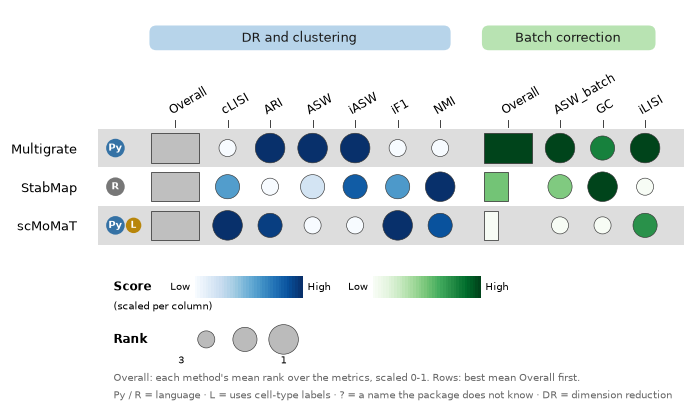

In [5]:
res.plot()